In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import IPython.display

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score

In [ ]:
#Place file destination into path
path = r"C:\parkinsons_proj\data\parkinsons.data"

df = pd.read_csv(path)
print(df.shape)

(195, 24)


# Data Preprocessing

In [52]:
#view features
display(df.columns.tolist())

['name',
 'MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'status',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

In [53]:
display(df.head(10))
#the read-me says that each patient was recorded around 6 times.
#for 31 patients with each having 6 recordings, that does not add to 195.
#there must be patients with more or less than 6 recordings
row_count_check = 31 * 6

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [54]:
#removes iteration number and adjacent underscore starting from right of string
#will be used to create grouping later when modeling
base_names = df['name'].str.rsplit('_', n=1).str[0]

#calculates for each instance the total number of records
instance_counts = base_names.value_counts()

has_more = (instance_counts > 6).any()
has_less = (instance_counts < 6).any()

if has_more:
    print("There are records greater than 6")
else:
    print("There are no records greater than 6")
if has_less:
    print("There are records less than 6")
else:
    print("There are no records less than 6")


instance_sum = instance_counts.sum()
print(f"there are {instance_sum} total instances")


There are records greater than 6
There are no records less than 6
there are 195 total instances


In [55]:
#create a new modified df with base_names for names for groupkfold
df_mod = df.copy()
df_mod['name'] = base_names

df_mod.head(10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


# Exploratory Data Analysis

## Missing Values

In [56]:
print(df_mod.isna().any())

name                False
MDVP:Fo(Hz)         False
MDVP:Fhi(Hz)        False
MDVP:Flo(Hz)        False
MDVP:Jitter(%)      False
MDVP:Jitter(Abs)    False
MDVP:RAP            False
MDVP:PPQ            False
Jitter:DDP          False
MDVP:Shimmer        False
MDVP:Shimmer(dB)    False
Shimmer:APQ3        False
Shimmer:APQ5        False
MDVP:APQ            False
Shimmer:DDA         False
NHR                 False
HNR                 False
status              False
RPDE                False
DFA                 False
spread1             False
spread2             False
D2                  False
PPE                 False
dtype: bool


## Duplicate Entries

In [57]:
if df_mod.duplicated().any():
    print("There are duplicates")
else:
    print("There are no duplicates")

There are no duplicates


## Class Distribution

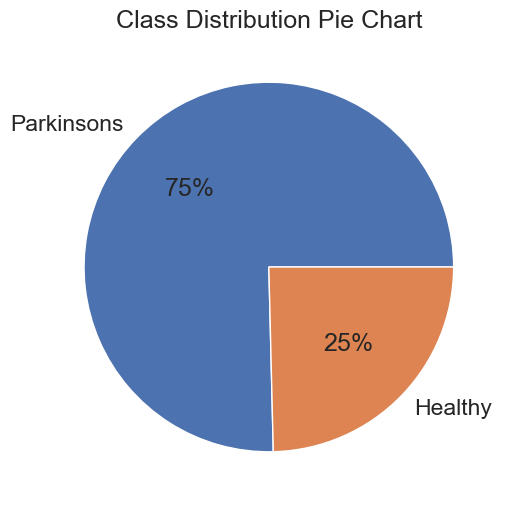

In [58]:
status_counts = df_mod['status'].value_counts()
labels = ['Parkinsons', 'Healthy']

sns.set_style("whitegrid")
sns.set_theme(font_scale=1.5)
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=labels, autopct='%.0f%%')
plt.title("Class Distribution Pie Chart")
plt.show()

• Due to the imbalnce between classes, different sampling methods need to be explored to find the best performing model.

## Feature Correlation

"High Values: {'spread1': 0.565, 'PPE': 0.531}"

"Medium Values: {'spread2': 0.455, 'MDVP:Shimmer': 0.367, 'MDVP:APQ': 0.364, 'MDVP:Shimmer(dB)': 0.351, 'Shimmer:APQ5': 0.351, 'Shimmer:APQ3': 0.348, 'Shimmer:DDA': 0.348, 'D2': 0.34, 'MDVP:Jitter(Abs)': 0.339, 'RPDE': 0.309}"

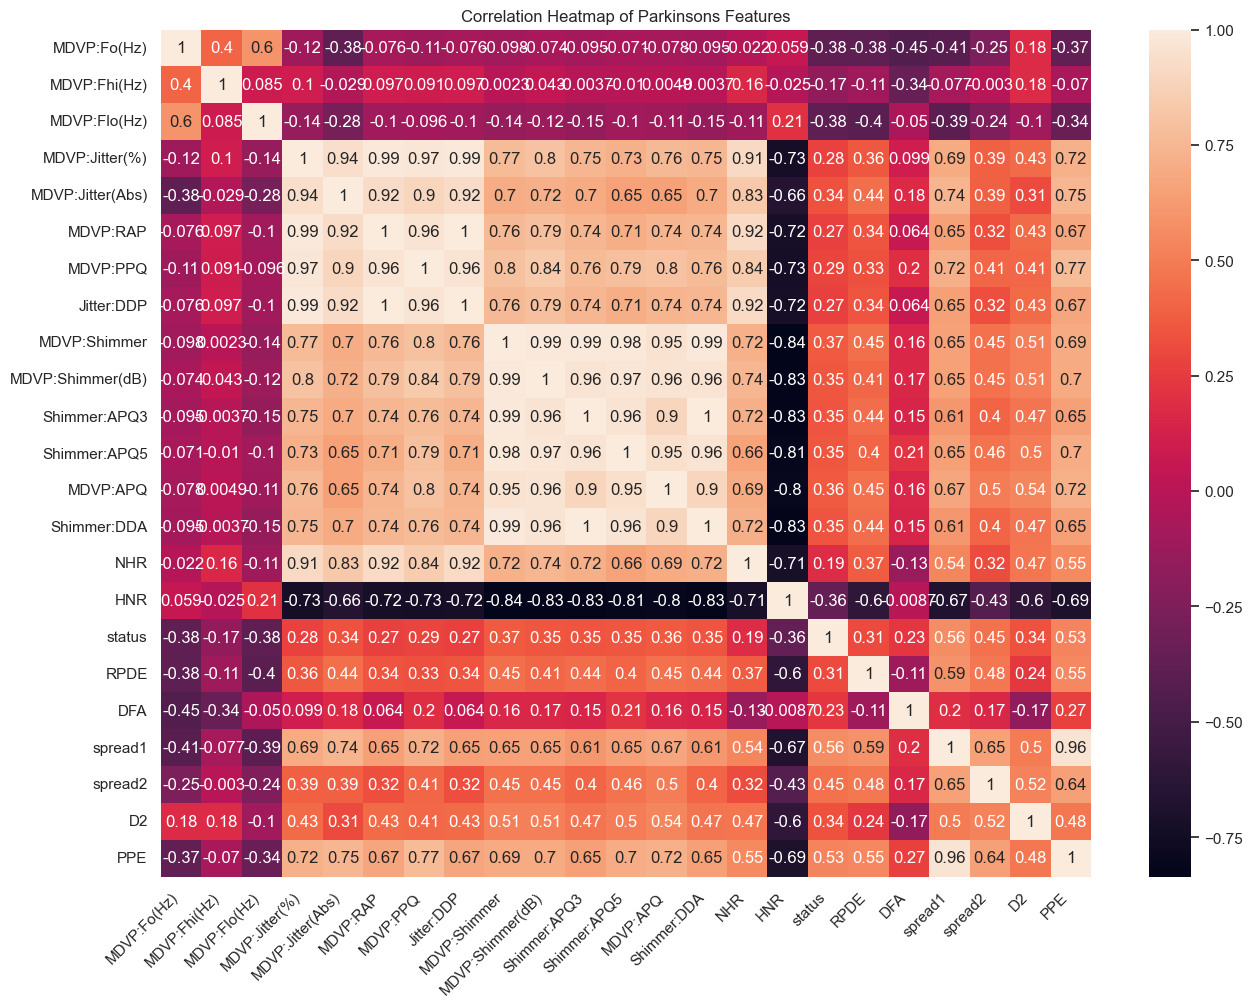

In [59]:
#Create list of features, leaving out name
feature_list = [col for col in df_mod.columns if col != 'name']

#compute the correlation matrix
corr_matrix = df_mod[feature_list].corr()

#set the target column and correlation value
target_col = 'status'

#extracts correlation values for the 'status' column against all other features
target_corr = corr_matrix[target_col].drop(target_col)

hi_thresh = 0.5
med_thresh = 0.3

hi_value_dict = {}
med_value_dict = {}

for index, value in target_corr.items():
    if (value > hi_thresh):
        hi_value_dict[index] = round(value, 3)
    elif (med_thresh < value < hi_thresh):
        med_value_dict[index] = round(value, 3)
    else:
        pass

#sort dicts by value
hi_value_dict = dict(sorted(hi_value_dict.items(), key=lambda item: item[1], reverse = True))
med_value_dict = dict(sorted(med_value_dict.items(), key=lambda item: item[1], reverse = True))

display(f"High Values: {hi_value_dict}")
display(f"Medium Values: {med_value_dict}")


plt.figure(figsize=(15,11))
sns.set_theme(font_scale=1)
sns.heatmap(corr_matrix, annot=True)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Heatmap of Parkinsons Features")
plt.show()

The feature heatmap above illustrates which features correlate highly with the 'status' classifier.

• The two features that have the highest values for correlation are:
1. spread1 = 0.565
2. PPE = 0.531
    - measures of variation in fundamental frequency


Both of these features are measures of fundamental frequency (ff) variation.

• A likely reason 'spread1' and 'PPE' have high correlations to 'status' is because a symptom of Parkinson's is reduced control over one's muscles. This causes parts of the body like the larynx, vocal cords, lips, and tongue to affect overall speech pattern to become more unpredictable.


• Features that are moderately related to determining Parkinsons are:
1. spread2 = 0.455
    - A measure of fundamental frequency variation
- 'spread2' is also a measure of ff variation, but has a significantly smaller correlation at 0.455. All three measures, however, are not three variations of the same thing; they all serve a unique purpose. Specifically, 'spread1' quantifies the overall spread of ff distribution on a logarithmic scale which evaluates macro-level pitch dynamics realtive to human hearing. 'Spread2' complements 'spread1' by targeting micro-variations across the frequency spectrum that it may not pick up. 'PPE' (Pitch Period Entropy) measures the randomness/entropy of pitch variations after filtering out normal, healthty voice fluctuations. (Gemini, personal communication, September 7, 2026)

<br>

2. MDVP:Shimmer = 0.367
3. MDVP:APQ = 0.364
4. MDVP:Shimmer(dB) = 0.351
5. Shimmer:APQ5 = 0.351
6. Shimmer:APQ3 = 0.348
7. Shimmer:DDA = 0.348
    - Several measures of variation in amplitude
- These features cluster around (~0.35-0.37), which is because they are all mathematical variations of the same data measure. Additionally, the heatmap shows mutual collinearity between each feature. Because of these near-idential correlations and collinearity, feature selection is needed to avoid multicollinearity

<br>

8. MDVP:Jitter(Abs) = 0.339
    - A measure of variation in fundamental frequency

<br>

9. D2 = 0.34
10. RPDE = 0.309
    - two nonlinear dynamical complexity measures


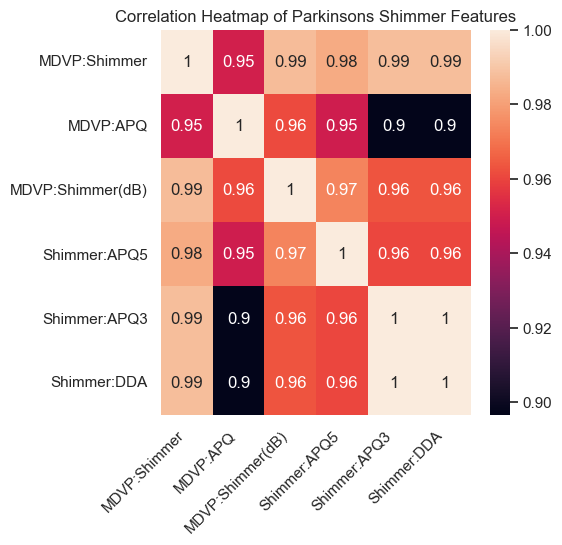

In [60]:
shimmer_features = ['MDVP:Shimmer', 'MDVP:APQ', 'MDVP:Shimmer(dB)', 'Shimmer:APQ5', 'Shimmer:APQ3', 'Shimmer:DDA']
shimmer_corr_matrix = df_mod[shimmer_features].corr()

plt.figure(figsize=(5,5))
sns.set_theme(font_scale=1)
sns.heatmap(shimmer_corr_matrix, annot=True)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Heatmap of Parkinsons Shimmer Features")
plt.show()

## Outlier Detection

In [61]:
features_to_ignore = ['status','name']
features_to_test = [col for col in df_mod.columns if col not in features_to_ignore]

def detect_outliers(df, features) -> list:
    features_with_outliers = []

    for feature in features:
        #calculate quartiles and iqr and up + ll
        q1 = df[feature].quantile(0.25)
        q3 = df[feature].quantile(0.75)

        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        #FIX: used .any() to check if filtered data is non-empty
        #did not have this before, and python throw an error because it couldn't convert a df
        #into a single true or false statement
        has_outliers = ((df[feature] < lower_limit) | (df[feature] > upper_limit)).any()
        
        if (has_outliers):
            #create subplots
            features_with_outliers.append(feature)
            
        else:
            pass

    return features_with_outliers

detect_outliers(df_mod, features_to_test)


['MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'spread1',
 'spread2',
 'D2',
 'PPE']

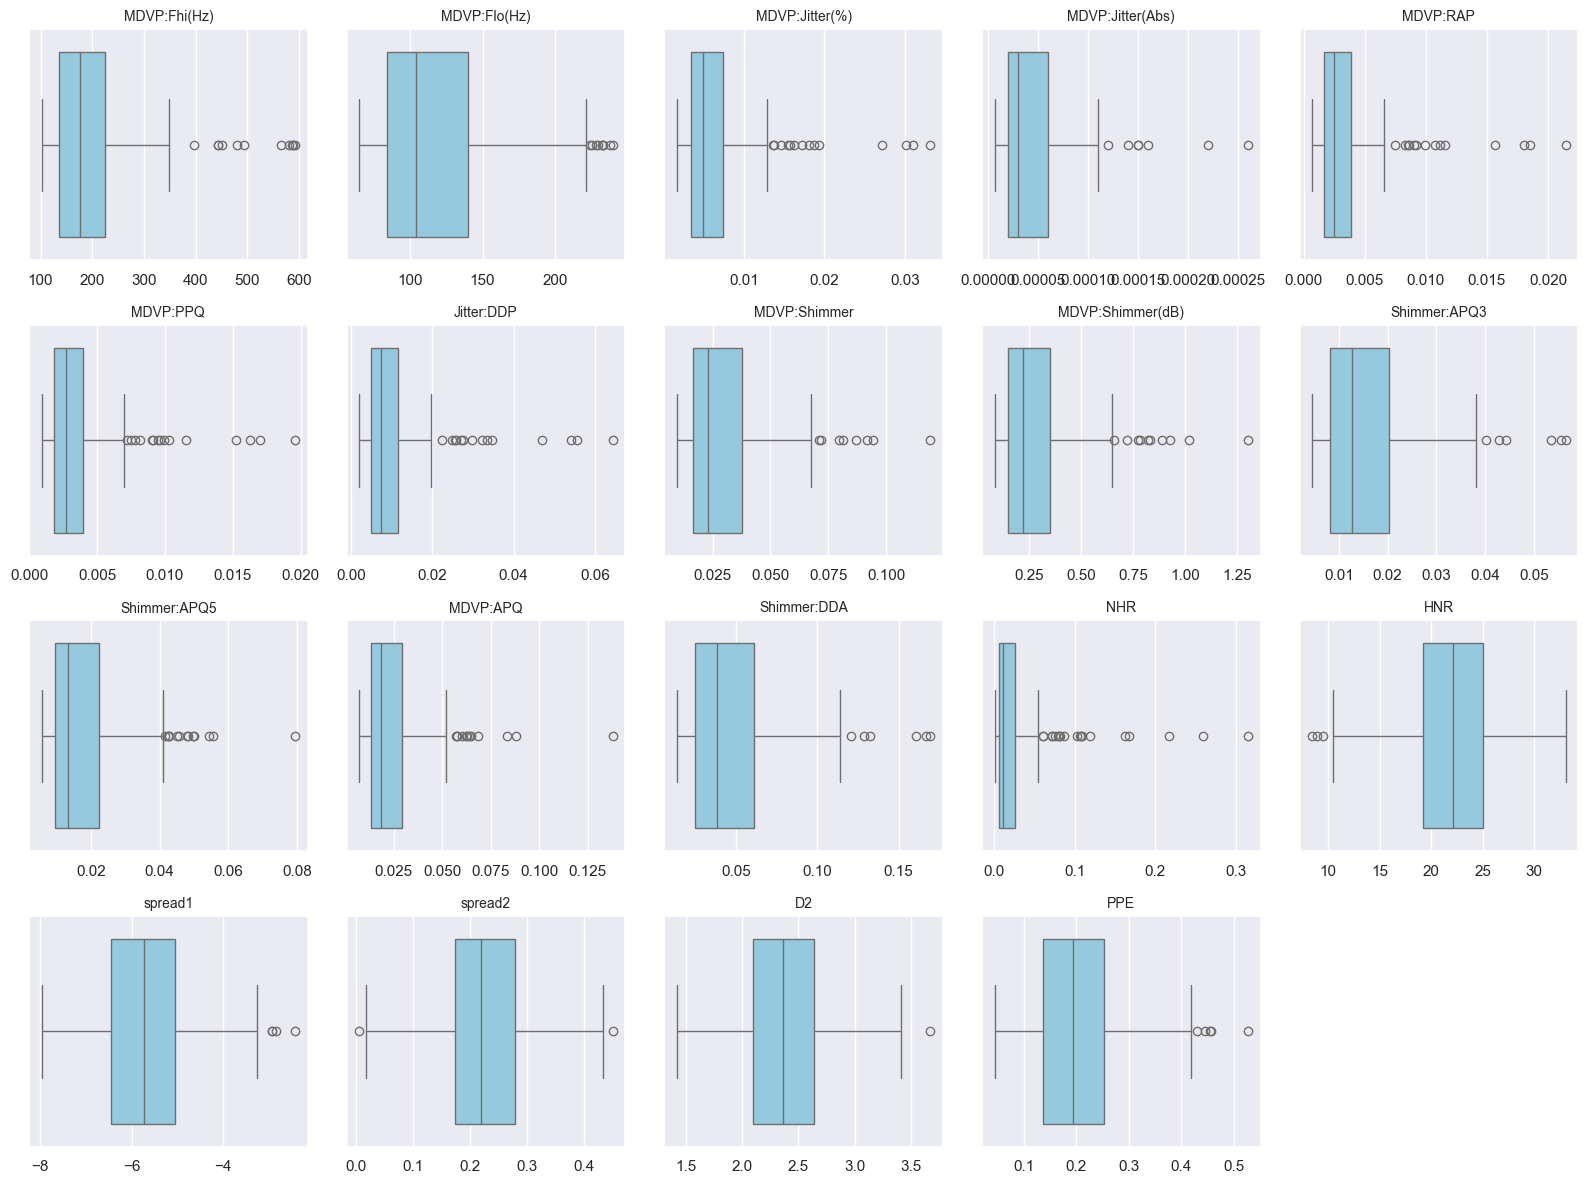

In [62]:
features_with_outliers = detect_outliers(df_mod, features_to_test)

def plot_outliers(df, features):
    fig, axes = plt.subplots(4, 5, figsize=(16,12))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.boxplot(x=df[col], ax=axes[i], color="skyblue")
        axes[i].set_title(col, fontsize = 10)
        axes[i].set(xlabel='', ylabel='')
        

    #gets rid of empty 20th plot 
    if len(features) < len(axes):
        for j in range(len(features), len(axes)):
            fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_outliers(df_mod, features_with_outliers) 

• The plots above all have outliers to different degrees; some datapoints are closer to the whiskers than others.

• In context to this study, it is normal and expected to have outliers when your data concerns human vocals as it tends to naturally vary, even for healthy individuals.

• Features like 'MDVP:Fhi(Hz)' and 'MDVP:Flo(Hz)' reflect the highs and lows of physical pitch limits. Additionally, jitter features measure the variation/instability of this frequency which can happen naturally and more so for those with Parkinson's.

• The result of this is that many of the plots are right-skewed, which violates the assumption of normality of residuals and affects distance-based algorithms like KNN or SVM without proper scaling and transformations.

• Instead of removing the outliers as they offer valid and valuable information, they will be transformed the fit model assumptions.

## Model Selection and Training

### Dataset to Train With + split

In [63]:
#===== SPLIT AND SCALE DATA =====
#feature of interest
X = df_mod.drop(columns=['status','name'])
y = df_mod['status']
#create grouping on name
groups = df_mod['name']

#perform 80% train, 20% test split
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.2,
    train_size=0.8,
    random_state=1,
    stratify=y
)

#initialize scaler
scaler = StandardScaler()

#fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

#transform test data
X_test_scaled = scaler.transform(X_test)

## Feature selection

• As mentioned earlier, feature selection is needed because the shimmer features all have similar correlations with one another. This suggests that they may hold redundant information that could lead to high variance and overfitting.

• L1-based feature selection will be used. When it sees two or more features that are extremely correlated, one will be arbitraility picked and the other set to zero. It forces the weights of less-important features to become 0, effectively removing said features from the model's equations.

In [64]:

# 1. Fit LinearSVC with strong regularization for feature selection (lasso)
lsvc = LinearSVC(C=0.1, penalty='l1', dual=False, random_state=1)
lsvc.fit(X_train_scaled, y_train)

# 2. Select model features
model = SelectFromModel(lsvc, prefit=True)

X_train_selected = model.transform(X_train_scaled)
X_test_selected = model.transform(X_test_scaled)

# Check results
selected_mask = model.get_support()
print(f"Features kept: {selected_mask.sum()} out of {X.shape[1]}")
display("Kept features:", X_train.columns[selected_mask].tolist())

Features kept: 7 out of 22


'Kept features:'

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Shimmer',
 'DFA',
 'spread1',
 'spread2',
 'D2']

• Interestingly, the feature that correlated the highest to 'status', 'PPE', was not one of the kept features. The most likely answer for this is that the Pearson correlation calculates a linear, pairwise relationship (two variables: 1 feature and 1 label at a time) while Lasso looks at how all the features work in conjunction with eachother. In lasso, when all the features were evaluated together, it was likely decieded that 'PPE' provided redundant information.

### SVM Model

In [98]:
#create pipeline
svm_pipeline = Pipeline([
    ('smote', SMOTE(random_state=1)),
    ('svm', SVC(random_state=1)),
])

#set up parameters
svm_params = {
    'svm__kernel':['linear','poly','rbf'],
    'svm__C':[0.1,1,10],
    'svm__gamma': [1, 0.1, 0.01, 0.001, 'scale']
}

#grouped cross-validation
cv = StratifiedGroupKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 1
)

#grid search
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=cv,
    scoring='f1' #default
)

#fit using training data and training groups
svm_grid.fit(
    X_train_selected,
    y_train,
    groups=groups_train
)

#get the best model
best_svm = svm_grid.best_estimator_

#Evaluate
svm_y_pred = best_svm.predict(X_test_selected)

Accuracy score: 0.8461538461538461
              precision    recall  f1-score   support

           0       1.00      0.40      0.57        10
           1       0.83      1.00      0.91        29

    accuracy                           0.85        39
   macro avg       0.91      0.70      0.74        39
weighted avg       0.87      0.85      0.82        39



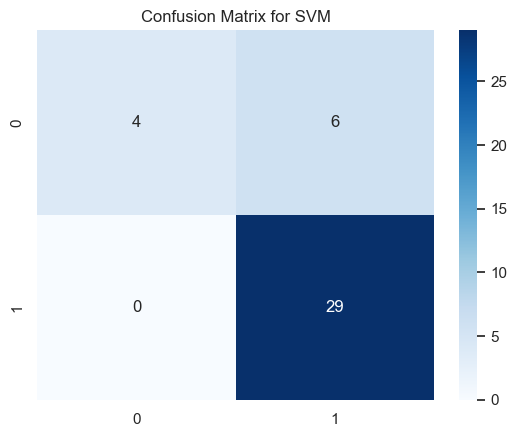

In [99]:
#check accuracy & recall
print(f"Accuracy score: {accuracy_score(y_test, svm_y_pred)}")

print(classification_report(y_test, svm_y_pred))

#confusion matrix
sns.heatmap(confusion_matrix(y_test,svm_y_pred), annot=True, fmt='d',cmap="Blues")
plt.title("Confusion Matrix for SVM")
plt.show()

## 5-Fold CV

In [67]:
#Best CV performance
print(f"Best CV F1: {svm_grid.best_score_:.2%}")

#Test predictions
svm_y_pred = best_svm.predict(X_test_selected)

#Test Performance
svm_f1 = f1_score(y_test, svm_y_pred)
svm_recall = recall_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred)

print(f"Test F1: {svm_f1:.2%}")
print(f"Test Recall: {svm_recall:.2%}")
print(f"Test Precision: {svm_precision:.2%}")

Best CV F1: 90.81%
Test F1: 90.62%
Test Recall: 100.00%
Test Precision: 82.86%


• The model achieved a test recall of 1.0 for Parkinson's Disease patient, meaning zero false negative diagnoses.

• Significance: High recall is important because it avoids false-negative diagnoses of the disease. With Parkinson's, it is important to begin treatment as soon as possible to slow its progression throughout the body. If not diagnosed, valuable time is lost

• Secondary Metric: F1 is the balance between precision and recall. While false positives are undesirable due to the psychological stress put on the patient and time spent taking follow-up tests, it's considerably less harmful than a missed diagnosis. A high F1-score maintains ssensitivity without generating unnecessary false alarms.